In [2]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [3]:
mnist_train = datasets.MNIST(
    root="./datasets",
    train=True,
    transform=transforms.ToTensor(),
    download=True
)
print("MNIST train dataset shape: ", mnist_train.data.shape)


MNIST train dataset shape:  torch.Size([60000, 28, 28])


In [4]:
mnist_test = datasets.MNIST(
    root="./datasets",
    train=False,
    transform=transforms.ToTensor(),
    download=True
)
print("MNIST test dataset shape: ", mnist_test.data.shape)

MNIST test dataset shape:  torch.Size([10000, 28, 28])


In [5]:
image, label = mnist_train[3]
print(image.shape)
image = image.reshape([28, 28])
print(image.shape)

torch.Size([1, 28, 28])
torch.Size([28, 28])


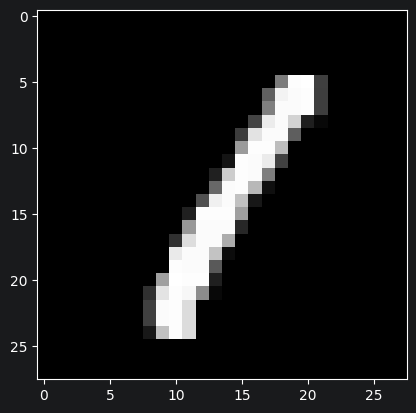

1


In [6]:
plt.imshow(image, cmap="gray")
plt.show()
print(label)

In [7]:
train_loader = torch.utils.data.DataLoader(
    mnist_train,
    batch_size=100,
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    mnist_test,
    batch_size=100,
    shuffle=False
)

In [8]:
data_train_iter = iter(train_loader)
image, labels = data_train_iter.__next__()
print(image.shape)
print(labels.shape)

torch.Size([100, 1, 28, 28])
torch.Size([100])


In [9]:
x = image.view(-1, 28*28)
print(x.shape)

torch.Size([100, 784])


$$
y_1 = \sum_i{x_iw_{i,1} + b_1}
$$

$$
y = xW + b
$$

In [10]:
W = torch.randn(784,10)/np.sqrt(784) # Xavier initialization

[Xe VS He habr](https://habr.com/ru/articles/932852/)


[Xavier in geeksforgeeks](https://www.geeksforgeeks.org/deep-learning/xavier-initialization/)


[Xe VS He Medium](https://medium.com/thedeephub/he-and-xavier-weight-initialization-functions-acedc5322ce5)

In [11]:
W.requires_grad = True
b = torch.zeros(10, requires_grad=True)
W, b

(tensor([[ 0.0739, -0.0063, -0.0739,  ...,  0.0130,  0.0595,  0.0194],
         [-0.0399,  0.0622,  0.0554,  ..., -0.0136, -0.0066, -0.0091],
         [ 0.0455,  0.0219, -0.0338,  ..., -0.0741, -0.0570,  0.0386],
         ...,
         [ 0.0730,  0.0296, -0.0738,  ..., -0.0119, -0.0247,  0.0072],
         [-0.0130, -0.0449,  0.0411,  ...,  0.0083,  0.0603,  0.0206],
         [-0.0444, -0.0321,  0.0393,  ..., -0.0321,  0.0336, -0.0276]],
        requires_grad=True),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True))

In [12]:
y = torch.matmul(x, W) + b
print((y[0, :]))

tensor([-0.5429, -0.4643,  0.2299, -0.0483, -0.2172,  0.1374, -0.4361, -0.0043,
        -0.1306, -0.0682], grad_fn=<SelectBackward0>)


$$
p(y_i) = softmax(y_i) = \frac{exp(y_i)}{\sum_i{exp(y_j)}}
$$

In [13]:
# py_eq = torch.exp(y)/torch.sum(torch.exp(y), dim=1, keepdim=True)
# print(py_eq[0])

tensor([0.0658, 0.0712, 0.1426, 0.1079, 0.0912, 0.1300, 0.0732, 0.1128, 0.0994,
        0.1058], grad_fn=<SelectBackward0>)


In [15]:
py = F.softmax(y, dim=1)
print(py[0])

tensor([0.0658, 0.0712, 0.1426, 0.1079, 0.0912, 0.1300, 0.0732, 0.1128, 0.0994,
        0.1058], grad_fn=<SelectBackward0>)


### Cross Entropy


$$
H_{y^′}(y) = -\sum{{y^′}_i log(y_i)}
$$

In [17]:
# cross_entropy_eq = torch.mean(-torch.log(py)[range(labels.shape[0]), labels])
# print(cross_entropy_eq)

tensor(2.3372, grad_fn=<MeanBackward0>)


In [18]:
cross_entropy = F.cross_entropy(y, labels)
print(cross_entropy)

tensor(2.3372, grad_fn=<NllLossBackward0>)


In [19]:
# Stochastic gradient descent
optimizer = torch.optim.SGD([W, b], lr=0.1)
cross_entropy.backward()
b.grad

tensor([-0.0567, -0.0842,  0.0901,  0.0431,  0.0346,  0.0769, -0.0483, -0.0566,
        -0.0104,  0.0115])

In [20]:
optimizer.step()
b

tensor([ 0.0057,  0.0084, -0.0090, -0.0043, -0.0035, -0.0077,  0.0048,  0.0057,
         0.0010, -0.0012], requires_grad=True)

In [22]:
print(b.grad)
optimizer.zero_grad()
print(b.grad)

tensor([-0.0567, -0.0842,  0.0901,  0.0431,  0.0346,  0.0769, -0.0483, -0.0566,
        -0.0104,  0.0115])
None


In [24]:
print(len(train_loader))
for images, labels in tqdm(train_loader):
    optimizer.zero_grad()
    x = images.view(-1, 28*28)
    y = torch.matmul(x, W) + b
    cross_entropy = F.cross_entropy(y, labels)

    cross_entropy.backward()
    optimizer.step()

600


100%|██████████| 600/600 [00:03<00:00, 161.63it/s]


In [26]:
correct = 0
total = len(mnist_test)
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        x = images.view(-1, 28*28)
        y = torch.matmul(x, W) + b
        pred = torch.argmax(y, dim=1)
        correct += torch.sum(pred == labels).float()
print(correct / total)

100%|██████████| 100/100 [00:00<00:00, 173.64it/s]

tensor(0.9014)


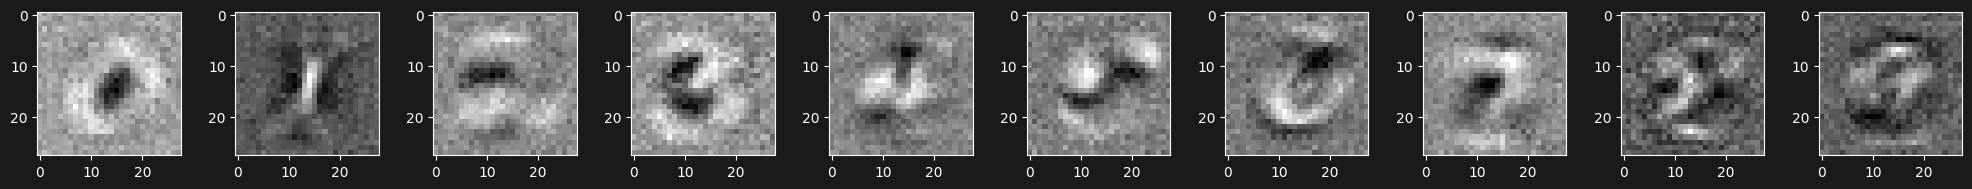

In [30]:
fig, ax = plt.subplots(1, 10, figsize=(20,2))
for i in range(10):
    ax[i].imshow(W[:, i].detach().view(28,28), cmap="gray")
    plt.tight_layout()